In [1]:
%run ../input/python-recipes/dhtml.py
%run ../input/python-recipes/load_kaggle_digits.py
%run ../input/python-recipes/classify_kaggle_digits.py
dhtml('Data Processing')

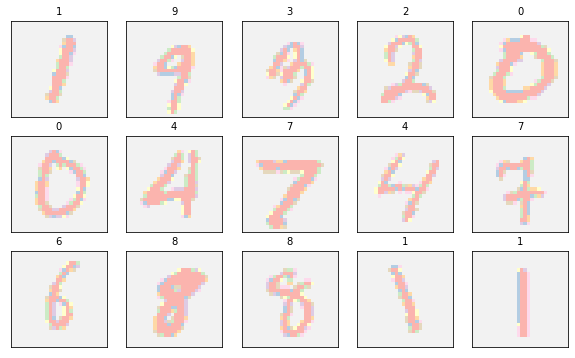

function outputs: 



,train,valid,test,global test
image shape,"(33600, 28, 28, 1)","(4200, 28, 28, 1)","(4200, 28, 28, 1)","(28000, 28, 28, 1)"
image type,float32,float32,float32,float32
label shape,"(33600,)","(4200,)","(4200,)",NaN
label type,int32,int32,int32,NaN


In [2]:
k=.75; cmap='Pastel1_r'
x_train,y_train,x_valid,y_valid,x_test,y_test,\
test_images,num_classes=\
load_kaggle_digits(k,cmap)

In [3]:
dhtml('Classification')

In [4]:
weights='weights.best.hdf5'
epochs=100; gen_epochs=30
cnn_model=cnn_model(num_classes)
train_history,generator_history=\
model_history(
    cnn_model,weights,epochs,gen_epochs,
    x_train,y_train,x_valid,y_valid)

Epoch 1/100

Epoch 00001: val_loss improved from inf to 0.13140, saving model to weights.best.hdf5
263/263 - 2s - loss: 0.4948 - sparse_categorical_accuracy: 0.8387 - sparse_top_3_categorical_accuracy: 0.9326 - val_loss: 0.1314 - val_sparse_categorical_accuracy: 0.9740 - val_sparse_top_3_categorical_accuracy: 0.9950
Epoch 2/100

Epoch 00002: val_loss improved from 0.13140 to 0.05539, saving model to weights.best.hdf5
263/263 - 2s - loss: 0.1079 - sparse_categorical_accuracy: 0.9672 - sparse_top_3_categorical_accuracy: 0.9955 - val_loss: 0.0554 - val_sparse_categorical_accuracy: 0.9840 - val_sparse_top_3_categorical_accuracy: 0.9986
Epoch 3/100

Epoch 00003: val_loss improved from 0.05539 to 0.04832, saving model to weights.best.hdf5
263/263 - 2s - loss: 0.0771 - sparse_categorical_accuracy: 0.9764 - sparse_top_3_categorical_accuracy: 0.9975 - val_loss: 0.0483 - val_sparse_categorical_accuracy: 0.9852 - val_sparse_top_3_categorical_accuracy: 0.9983
Epoch 4/100

Epoch 00004: val_loss imp

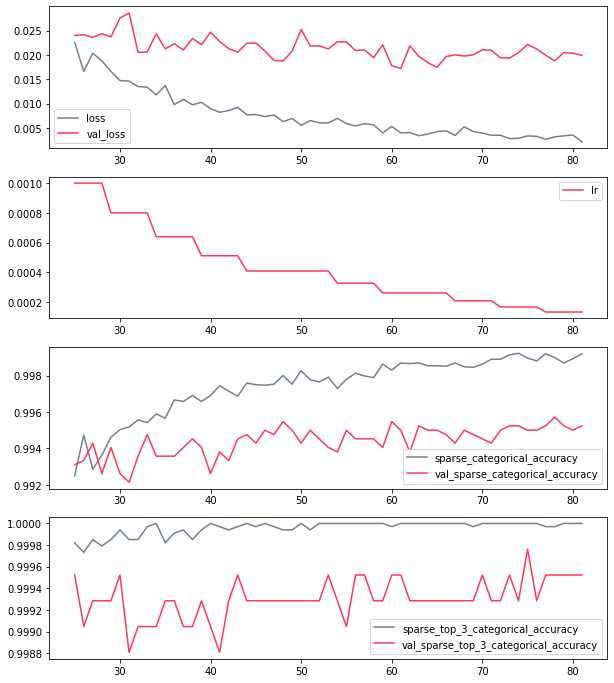

,78,79,80,81
loss,0.003159,0.003359,0.003539,0.002128
sparse_categorical_accuracy,0.998988,0.998690,0.998929,0.999196
sparse_top_3_categorical_accuracy,0.999970,1.000000,1.000000,1.000000
val_loss,0.018785,0.020486,0.020350,0.019929
val_sparse_categorical_accuracy,0.995714,0.995238,0.995000,0.995238
val_sparse_top_3_categorical_accuracy,0.999524,0.999524,0.999524,0.999524
lr,0.000134,0.000134,0.000134,0.000134


In [5]:
color=c1; start=25
plot_history(train_history,start,color)

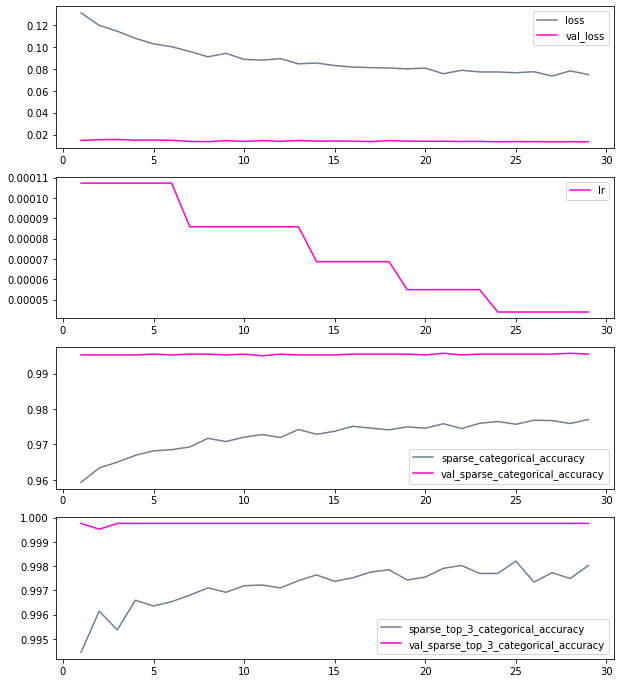

,26,27,28,29
loss,0.077506,0.073563,0.078256,0.074873
sparse_categorical_accuracy,0.976816,0.976727,0.975890,0.977026
sparse_top_3_categorical_accuracy,0.997341,0.997729,0.997490,0.998028
val_loss,0.013458,0.013302,0.013362,0.013336
val_sparse_categorical_accuracy,0.995476,0.995476,0.995714,0.995476
val_sparse_top_3_categorical_accuracy,0.999762,0.999762,0.999762,0.999762
lr,0.000044,0.000044,0.000044,0.000044


In [6]:
color=c10; start=1
plot_history(generator_history,start,color)

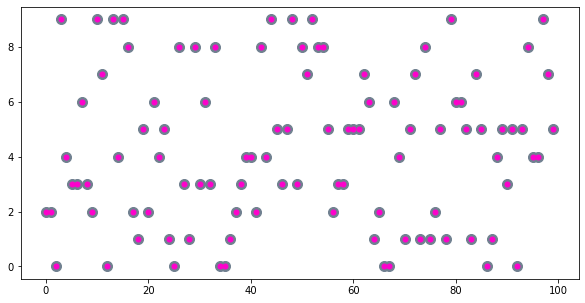

cnn scores: 
 [0.019099179655313492, 0.9940476417541504, 1.0]
cnn error: 0.60%
classification report: 

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       408
           1       1.00      1.00      1.00       469
           2       1.00      1.00      1.00       423
           3       1.00      1.00      1.00       436
           4       0.99      1.00      0.99       410
           5       1.00      0.99      0.99       394
           6       1.00      1.00      1.00       435
           7       0.99      0.99      0.99       423
           8       0.99      0.99      0.99       406
           9       0.99      0.98      0.99       396

    accuracy                           0.99      4200
   macro avg       0.99      0.99      0.99      4200
weighted avg       0.99      0.99      0.99      4200

confusion matrix: 

[[405   0   0   0   0   0   2   0   0   1]
 [  0 467   0   0   0   0   0   1   1   0]
 [  0   1 421   1   0   0   0  

In [7]:
num_test=100
model_evaluation(cnn_model,x_test,y_test,
                 weights,color,num_test)

In [8]:
dhtml('Predictions')

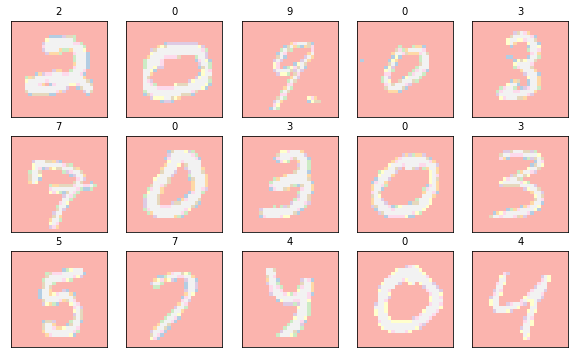

In [9]:
cnn_model.load_weights(weights)
predict_test_labels=\
cnn_model.predict_classes(test_images)
submission=pd.DataFrame(
    {'ImageId':range(1,len(predict_test_labels)+1), 
     'Label':predict_test_labels})
submission.to_csv('kaggle_digits.csv',index=False)
fig=pl.figure(figsize=(10,6))
for i in range(15):
    ax=fig.add_subplot(3,5,i+1,xticks=[],yticks=[])
    ax.imshow(test_images[i].reshape(28,28),
              cmap=pl.get_cmap('Pastel1'))
    ax.set_title('%d'%submission['Label'][i],
                 fontsize=10)
pl.show()